# Finite Difference Methods in 1D
by Manuel A. Diaz on 20.03.2026

### Preamble

In [1]:
# Packages
import numpy as np
import sympy as sp

# Preaty print
from IPython.display import Math, display
from matplotlib import pyplot as plt

# Constants
π = np.pi
ξ = 0.1

### Set Test

In [2]:
# Domain
N = 64  # number of grid points
x = np.linspace(0.0, 1.0, N, endpoint=False)  # hack for periodic function!
Δx = x[1] - x[0]  # `h` in Leveque's convention

In [3]:
# Test function and Exact expectation
u = np.sin(4 * π * x)
du_exact = 4 * π * np.cos(4 * π * x)

### Matrix-Free FD Operators

In [4]:
# Assuming periodic Boundary conditions!


def left_biased(u, h):
    """First-order backward (left-biased) difference: (u_i - u_{i-1}) / h"""
    return (u - np.roll(u, 1)) / h  # roll(+1) --> u_{i-1}


def right_biased(u, h):
    """First-order forward (right-biased) difference: (u_{i+1} - u_i) / h"""
    return (np.roll(u, -1) - u) / h  # roll(-1) --> u_{i+1}


def central(u, h):
    """Second-order central difference: (u_{i+1} - u_{i-1}) / (2 h)"""
    return (np.roll(u, -1) - np.roll(u, 1)) / (2 * h)

In [5]:
# Compute derivatives
du_left = left_biased(u, Δx)
du_right = right_biased(u, Δx)
du_central = central(u, Δx)

# Compute L1 error norms
l1_left = Δx * np.sum(np.abs(du_left - du_exact))
l1_right = Δx * np.sum(np.abs(du_right - du_exact))
l1_central = Δx * np.sum(np.abs(du_central - du_exact))

print("l1 error norms")
print(f"  Left-biased  (backward, O(Δx))  : {l1_left:.6e}")
print(f"  Right-biased (forward,  O(Δx))  : {l1_right:.6e}")
print(f"  Central      (O(Δx²))           : {l1_central:.6e}")

l1 error norms
  Left-biased  (backward, O(Δx))  : 7.853982e-01
  Right-biased (forward,  O(Δx))  : 7.853982e-01
  Central      (O(Δx²))           : 5.114025e-02


### Matrix-based FD Operators

In [6]:
# Assuming periodic Boundary conditions!

N_example = 6
h = sp.symbols("h", positive=True)


def build_Dm_sym(N, h):
    D = sp.zeros(N, N)
    for i in range(N):
        D[i, i] = 1
        D[i, (i - 1) % N] = -1  # N handles the periodic cornerh
    return D / h


def build_Dp_sym(N, h):
    D = sp.zeros(N, N)
    for i in range(N):
        D[i, i] = -1
        D[i, (i + 1) % N] = 1  # N handles the periodic corner
    return D / h


def build_D0_sym(N, h):
    D = sp.zeros(N, N)
    for i in range(N):
        D[i, (i + 1) % N] = 0.5
        D[i, (i - 1) % N] = -0.5
    return D / h


Dm = build_Dm_sym(N_example, h)
Dp = build_Dp_sym(N_example, h)
D0 = build_D0_sym(N_example, h)

display(Math(r"D^- = " + sp.latex(Dm)))
display(Math(r"D^+ = " + sp.latex(Dp)))
display(Math(r"D^0 = " + sp.latex(D0)))

# Verify
# sp.simplify(D0 - (Dp + Dm) / 2)  # should return zero matrix

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [7]:
# Assuming periodic Boundary conditions!


def build_Dm(N, h):  # D-  left-biased (backward, O(h))
    """(D- u)_i = (u_i - u_{i-1}) / h"""
    D = (np.diag(np.ones(N)) - np.diag(np.ones(N - 1), -1)) / h
    D[0, N - 1] = -1.0 / h  # periodic corner
    return D


def build_Dp(N, h):  # D+  right-biased (forward,  O(h))
    """(D+ u)_i = (u_{i+1} - u_i) / h"""
    D = (np.diag(np.ones(N - 1), 1) - np.diag(np.ones(N))) / h
    D[N - 1, 0] = 1.0 / h  # periodic corner
    return D


def build_D0(N, h):  # D0  central (O(h²))
    """(D0 u)_i = (u_{i+1} - u_{i-1}) / (2 h)"""
    D = (np.diag(np.ones(N - 1), 1) - np.diag(np.ones(N - 1), -1)) / (2 * h)
    D[0, N - 1] = -1.0 / (2 * h)  # periodic corners
    D[N - 1, 0] = 1.0 / (2 * h)
    return D

l1 error norms
  Left-biased  (backward, O(Δx))  : 7.853982e-01
  Right-biased (forward,  O(Δx))  : 7.853982e-01
  Central      (O(Δx²))           : 5.114025e-02


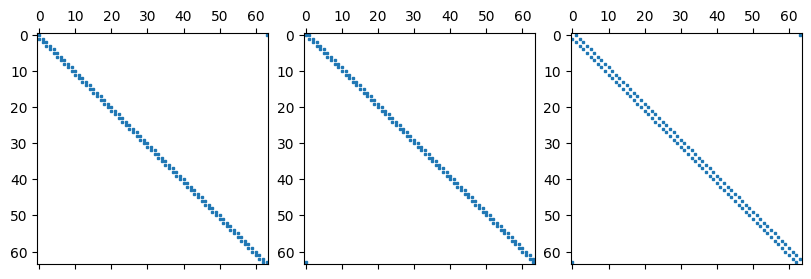

In [8]:
# Build operators
Dm = build_Dm(N, Δx)
Dp = build_Dp(N, Δx)
D0 = build_D0(N, Δx)

# CHECK
fig, ax = plt.subplots(1, 3, figsize=(8, 12), constrained_layout=True)
ax[0].spy(Dm, markersize=2, precision=1e-12)
ax[1].spy(Dp, markersize=2, precision=1e-12)
ax[2].spy(D0, markersize=2, precision=1e-12)

# Apply operators
du_Dm = Dm @ u
du_Dp = Dp @ u
du_D0 = D0 @ u

# Compute L1 error norms
l1_Dm = Δx * np.sum(np.abs(du_Dm - du_exact))
l1_Dp = Δx * np.sum(np.abs(du_Dp - du_exact))
l1_D0 = Δx * np.sum(np.abs(du_D0 - du_exact))

# Compute L1 error norms
print("l1 error norms")
print(f"  Left-biased  (backward, O(Δx))  : {l1_Dm:.6e}")
print(f"  Right-biased (forward,  O(Δx))  : {l1_Dp:.6e}")
print(f"  Central      (O(Δx²))           : {l1_D0:.6e}")

### Plot results

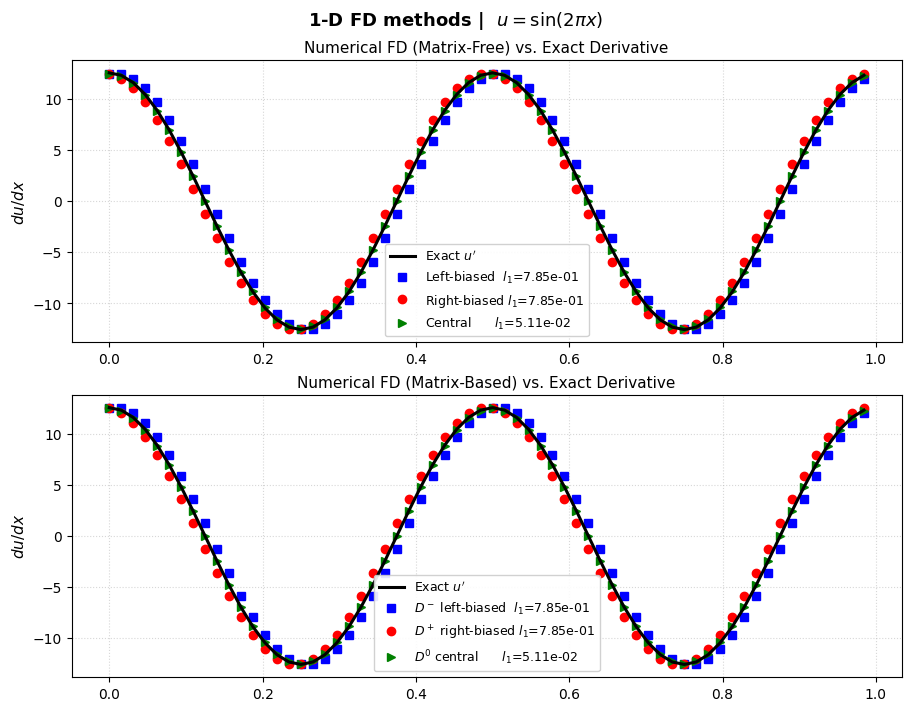

Figure saved.


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), constrained_layout=True)
fig.suptitle("1-D FD methods |  $u = \\sin(2\\pi x)$", fontsize=13, fontweight="bold")

ax = axes[0]
ax.plot(x, du_exact, "k-", lw=2.2, label="Exact $u'$", zorder=5)
ax.plot(x, du_left, "bs", lw=1.5, label=f"Left-biased  $l_1$={l1_left:.2e}")
ax.plot(x, du_right, "ro", lw=1.8, label=f"Right-biased $l_1$={l1_right:.2e}")
ax.plot(x, du_central, "g>", lw=1.5, label=f"Central      $l_1$={l1_central:.2e}")
ax.set_ylabel("$du/dx$", fontsize=11)
ax.set_title("Numerical FD (Matrix-Free) vs. Exact Derivative", fontsize=11)
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, linestyle=":", alpha=0.5)

ax = axes[1]
ax.plot(x, du_exact, "k-", lw=2.2, label="Exact $u'$", zorder=5)
ax.plot(x, du_Dm, "bs", lw=1.5, label=f"$D^-$ left-biased  $l_1$={l1_Dm:.2e}")
ax.plot(x, du_Dp, "ro", lw=1.8, label=f"$D^+$ right-biased $l_1$={l1_Dp:.2e}")
ax.plot(x, du_D0, "g>", lw=1.5, label=f"$D^0$ central      $l_1$={l1_D0:.2e}")
ax.set_ylabel(r"$du/dx$", fontsize=11)
ax.set_title("Numerical FD (Matrix-Based) vs. Exact Derivative", fontsize=11)
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, linestyle=":", alpha=0.5)

# plt.savefig("FDM1d.png", dpi=150)
plt.show()
print("Figure saved.")

# Operators Errors

In [10]:
N_list = [10, 20, 100, 200, 1000]  # grid size
h_list = np.zeros(len(N_list))
l1_Dm = np.zeros(len(N_list))
l1_Dp = np.zeros(len(N_list))
l1_D0 = np.zeros(len(N_list))

for i in range(len(N_list)):
    # Set Domain
    N = N_list[i]
    x = np.linspace(0.0, 1.0, N, endpoint=False)  # periodic function
    Δx = x[1] - x[0]
    h_list[i] = Δx

    # Periodic function
    u = np.sin(4 * π * x)

    # Exact solution
    du_exact = 4 * π * np.cos(4 * π * x)

    # Numerical approximation
    du_Dm = build_Dm(N, Δx) @ u
    du_Dp = build_Dp(N, Δx) @ u
    du_D0 = build_D0(N, Δx) @ u

    # Compute error
    l1_Dm[i] = Δx * np.sum(np.abs(du_Dm - du_exact))
    l1_Dp[i] = Δx * np.sum(np.abs(du_Dp - du_exact))
    l1_D0[i] = Δx * np.sum(np.abs(du_D0 - du_exact))

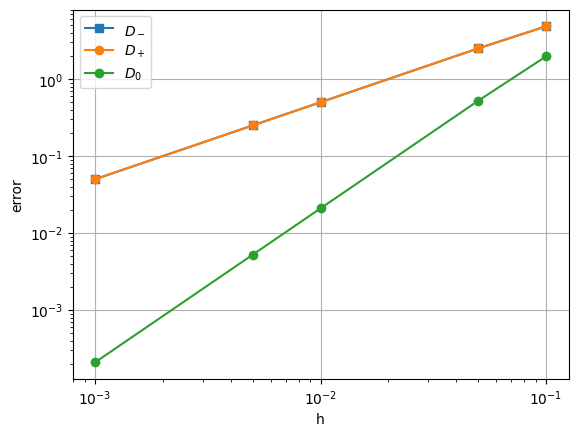

In [15]:
plt.loglog(h_list, l1_Dm, "-s", label="$D_-$")
plt.loglog(h_list, l1_Dp, "-o", label="$D_+$")
plt.loglog(h_list, l1_D0, "-o", label="$D_0$")
plt.xlabel("h")
plt.ylabel("error")
plt.grid()
plt.legend()
plt.show()

Compute the order of accuracy (OOA):
$$ p \approx \frac{\log(error_{i-1})-\log(error_{i})}{\log(h_{i-1})-\log(h_{i})} \equiv \frac{\log(error_{i-1}/error_{i})}{\log(h_{i-1}/h_{i})}$$


In [12]:
def compute_order(h, err):
    p = np.zeros(len(h))
    for i in range(1, len(h)):
        p[i] = np.log(err[i - 1] / err[i]) / np.log(h[i - 1] / h[i])
    return p


p_Dm = compute_order(h_list, l1_Dm)
p_Dp = compute_order(h_list, l1_Dp)
p_D0 = compute_order(h_list, l1_D0)

In [13]:
from prettytable import PrettyTable as PT

table = PT()

# Column names
table.field_names = [
    "N",
    "h",
    "L1 Error D-",
    "Order D-",
    "L1 Error D+",
    "Order D+",
    "L1 Error D0",
    "Order D0",
]

for i in range(len(N_list)):
    row = [
        N_list[i],
        f"{h_list[i]:.3e}",
        f"{l1_Dm[i]:.3e}",
        f"{p_Dm[i]:.2f}" if i > 0 else "-",
        f"{l1_Dp[i]:.3e}",
        f"{p_Dp[i]:.2f}" if i > 0 else "-",
        f"{l1_D0[i]:.3e}",
        f"{p_D0[i]:.2f}" if i > 0 else "-",
    ]
    table.add_row(row)

print(table)

+------+-----------+-------------+----------+-------------+----------+-------------+----------+
|  N   |     h     | L1 Error D- | Order D- | L1 Error D+ | Order D+ | L1 Error D0 | Order D0 |
+------+-----------+-------------+----------+-------------+----------+-------------+----------+
|  10  | 1.000e-01 |  4.864e+00  |    -     |  4.864e+00  |    -     |  1.978e+00  |    -     |
|  20  | 5.000e-02 |  2.513e+00  |   0.95   |  2.513e+00  |   0.95   |  5.247e-01  |   1.91   |
| 100  | 1.000e-02 |  5.027e-01  |   1.00   |  5.027e-01  |   1.00   |  2.105e-02  |   2.00   |
| 200  | 5.000e-03 |  2.513e-01  |   1.00   |  2.513e-01  |   1.00   |  5.261e-03  |   2.00   |
| 1000 | 1.000e-03 |  5.027e-02  |   1.00   |  5.027e-02  |   1.00   |  2.105e-04  |   2.00   |
+------+-----------+-------------+----------+-------------+----------+-------------+----------+


# How about non-periodic functions?

Long story short: we need to build an approximation of the boundary conditions. 

Let consider a prescribed boundary condition (also called Dirichlet BCs).
We cannot use centered schemes at the boundaries. We need to use a biased scheme!

There are two approaches to build such schemes:
* Taylor table algorithm (like http://web.media.mit.edu/~crtaylor/calculator.html)
* Fornberg Weights algorihtm (Fornberg paper of 1998)